In [1]:
pip install pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 30.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 54.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]2m1/2 [pandas]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib


Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
path = '/Users/teniolaadediran/Desktop/uni/year 4.1/thesis/ACID_Final_Data.csv'
#only keeping necessary columns
keep = ['condition','gender','GAD_1','GAD_2','GAD_3','GAD_4','GAD_5','GAD_6','GAD_7','msh_1','msh_2','msh_3','msh_4','msh_5','ipd','ipd_setting','postssq_ts','ssqts_change']
def load_processed(path,keep,skip_first=13):
    base = pd.read_csv(path)
    out = base.loc[:,keep].iloc[skip_first:].reset_index(drop=True).copy()
    return base, out
base,df = load_processed(path,keep)

In [6]:
print("Rows:",len(df),'Colounns', df.shape[1])

Rows: 138 Colounns 18


In [7]:
#changing the range from 1-4 to 0-3
gad_cols = ['GAD_1','GAD_2','GAD_3','GAD_4','GAD_5','GAD_6','GAD_7']
df[gad_cols] = df[gad_cols].apply(pd.to_numeric,errors = 'coerce')
map_dict = {1:0, 2:1, 3:2, 4:3}
df[gad_cols] = df[gad_cols].apply(lambda col: col.map(map_dict).fillna(col))
df_recode = df.to_csv("ACID_Final_Data_recode",index= False)


In [8]:
#male =0,female =1
df['gender']= df['gender'].replace({1:0,2:1})

In [9]:
#classifying each person's anxiety
df['GAD_Total'] = df[gad_cols].sum(axis=1)
def categorize_anxiety(score):
    if pd.isna(score):
        return None
    elif score <=4:
        return 'Minimal anxiety'
    elif score <=9:
        return 'Mild anxiety'
    elif score <=14:
        return 'Moderate anxiety'
    else:
        return 'Severe anxiety'
    
df['GAD_Level'] = df['GAD_Total'].apply(categorize_anxiety)


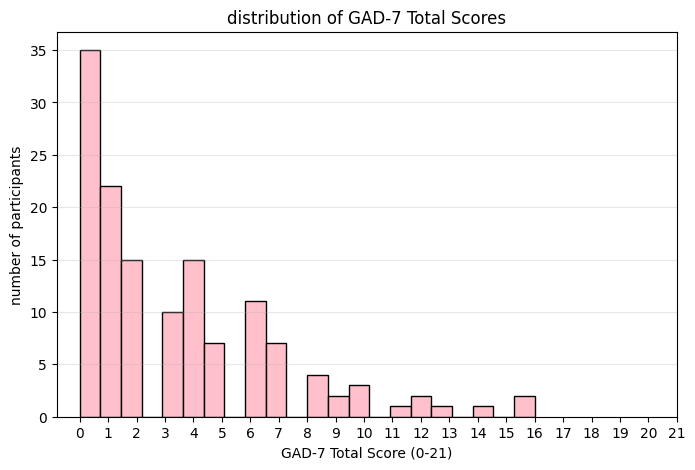

In [10]:
#distribution of scores
plt.figure(figsize=(8,5))
plt.hist(df['GAD_Total'],bins =22,edgecolor='black',color='pink')
plt.title('distribution of GAD-7 Total Scores')
plt.xlabel('GAD-7 Total Score (0-21)')
plt.ylabel('number of participants')
plt.xticks(range(0,22))
plt.grid(axis='y',alpha=0.3)
plt.show()

In [11]:
#0-1 normalize ssqts_change
df['ssqts_change']= pd.to_numeric(df['ssqts_change'],errors='coerce')
df['ssqts_change_norm']= (df['ssqts_change']-df['ssqts_change'].min())/(df['ssqts_change'].max()-df['ssqts_change'].min())

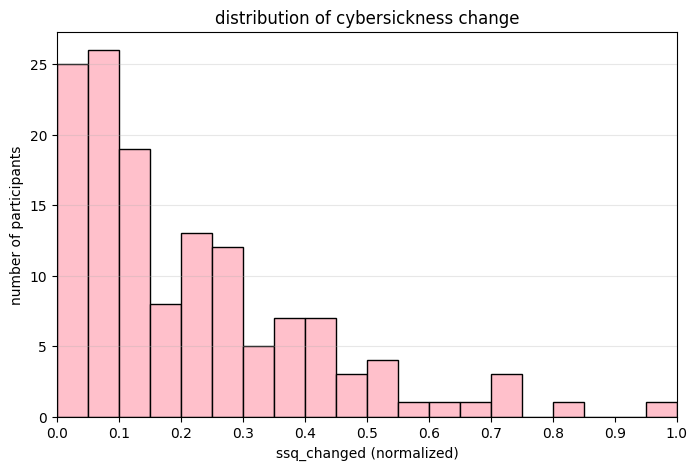

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df['ssqts_change_norm'],bins =20,edgecolor='black',color='pink')
plt.title('distribution of cybersickness change')
plt.xlabel('ssq_changed (normalized)')
plt.ylabel('number of participants')
plt.xticks(np.linspace(0,1,11))
plt.xlim(0,1)
plt.grid(axis='y',alpha=0.3)
plt.show()

In [13]:
#classifying postssq scores
df['postssq_ts'] =pd.to_numeric(df['postssq_ts'],errors = 'coerce')
if 'cybersick_binary_15' not in df.columns:
    df['cybersick_binary_15'] = (df['postssq_ts']>=15).astype(int)

def ssq_severity(ts):
    if pd.isna(ts):
        return None
    if ts< 15: 
        return 'Minimal'
    if ts <40:
        return 'Mild'
    if ts <60:
        return 'Moderate'
    return 'Severe'
if 'ssq_severity' not in df.columns:
    df['ssq_severity'] = df['postssq_ts'].apply(ssq_severity)


In [14]:
df['ssq_severity'].describe()

count         137
unique          4
top       Minimal
freq           40
Name: ssq_severity, dtype: object

In [15]:
print(df['ssq_severity'].value_counts().sort_index())

ssq_severity
Mild        34
Minimal     40
Moderate    23
Severe      40
Name: count, dtype: int64


In [16]:
#one hot encoding condition column
df = pd.get_dummies(df, columns =['condition'], prefix='cond',drop_first=True)

In [17]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [18]:
#data split
from sklearn.model_selection import train_test_split
X = df[['gender','GAD_Total','cond_2','cond_3']]
y = df['cybersick_binary_15']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)


In [19]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


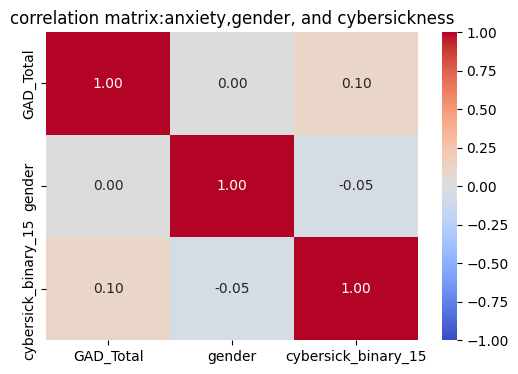

In [20]:
import seaborn as sns

corr = df[['GAD_Total','gender','cybersick_binary_15']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr,annot=True,fmt= ".2f",cmap='coolwarm',vmin=-1,vmax=1)
plt.title('correlation matrix:anxiety,gender, and cybersickness')
plt.show()

In [21]:
#baseline  model
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X,y)
baseline_pred = dummy.predict(X)

baseline_macro_f1 = f1_score(y,baseline_pred,average='macro')
print("baseline macro F1:",baseline_macro_f1)

baseline macro F1: 0.4127659574468085


In [22]:
#logistic regression
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold,cross_val_score

L_g = LogisticRegression(max_iter=1000)
L_g_pipeline = Pipeline([('smote',SMOTE(random_state=42)),('model',L_g)])

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

scores_L_g = cross_val_score(L_g_pipeline,X,y,cv=cv,scoring='f1_macro')
print("Logistics Regression Macro F1 Scores:", scores_L_g)
print ("Mean Macro F1:", scores_L_g.mean())

Logistics Regression Macro F1 Scores: [0.64153627 0.53544495 0.825      0.64540338 0.57142857]
Mean Macro F1: 0.6437626337728279


In [23]:
lr_full = LogisticRegression(max_iter=1000)
lr_full.fit(X, y)
probs = lr_full.predict_proba(X)[:,1]
ll_model = np.sum(y*np.log(probs)+(1-y)*np.log(1-probs))
p_null = np.mean(y)
ll_null = np.sum(y*np.log(p_null)+(1-y)*np.log(1-p_null))
mcfadden_r2 =1-(ll_model/ll_null)

print("McFadden's Pseudo R^2:",mcfadden_r2)

McFadden's Pseudo R^2: 0.07135996423664714


In [24]:
pip install imblearn

  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)
Note: you may need to restart the kernel to use updated packages.


In [25]:
#random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=500,max_depth= None,class_weight= None,random_state=42)
pipeline_rf = Pipeline([('smote',SMOTE(random_state=42)),('model',rf)])

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

scores_rf = cross_val_score(pipeline_rf,X,y,cv=cv,scoring='f1_macro')
print(scores_rf,scores_rf.mean())

[0.53333333 0.50877193 0.40813008 0.44197138 0.44411765] 0.46726487493307706


In [26]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [27]:
#LightGBM model
from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier(n_estimators = 300,max_depth = 3, learning_rate = 0.05, 
                          subsample = 0.8, colsample_bytree = 0.8, random_state = 42 )

lgbm_pipeline = Pipeline([('smote', SMOTE(random_state=42)), ('model',lgbm_model)])

cv =StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

lgbm_scores = cross_val_score(lgbm_pipeline,X,y,scoring='f1_macro',cv=cv)

print("LightGBM Macro F1 Scores:", lgbm_scores)
print("Mean Macro F1:", lgbm_scores.mean())

OSError: dlopen(/Users/teniolaadediran/opt/anaconda3/envs/thesis-ml/lib/python3.11/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <8FC36893-94B8-343C-9D9F-4CCBFE81B89B> /Users/teniolaadediran/opt/anaconda3/envs/thesis-ml/lib/python3.11/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libom

In [ ]:
#table X 

results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "LightGBM"],
    "Fold 1": [scores_L_g[0], scores_rf[0], lgbm_scores[0]],
    "Fold 2": [scores_L_g[1], scores_rf[1], lgbm_scores[1]],
    "Fold 3": [scores_L_g[2], scores_rf[2], lgbm_scores[2]],
    "Fold 4": [scores_L_g[3], scores_rf[3], lgbm_scores[3]],
    "Fold 5": [scores_L_g[4], scores_rf[4], lgbm_scores[4]],
})


results_df["Mean Macro F1"] = results_df[["Fold 1","Fold 2","Fold 3","Fold 4","Fold 5"]].mean(axis=1)

results_df

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean Macro F1
0,Logistic Regression,0.641536,0.535445,0.82500,0.645403,0.571429,0.643763
1,Random Forest,0.533333,0.508772,0.40813,0.441971,0.444118,0.467265
2,LightGBM,0.533333,0.535445,0.56250,0.584615,0.523529,0.547885


In [ ]:
from sklearn.metrics import confusion_matrix
models = {
    "Logistic Regression": L_g,
    "Random Forest": rf,
    "LightGBM":lgbm_model
}

plt.figure(figsize=(12,4))
i=1

for name, model in models.items():
    plt.subplot(1,3,i)
    y_pred = model.predict(X)
    cm = confusion_matrix(y,y_pred)
    sns.heatmap(cm,annot=True,fmt='d',cmap="Blues")
    plt.title(name)
    plt.xlabel('predicted')
    plt.ylabel('actual')
    i+=1
plt.tight_layout()
plt.show()

NameError: name 'lgbm_model' is not defined

In [28]:
import lightgbm as lgb
print(lgb.__version__)


OSError: dlopen(/Users/teniolaadediran/opt/anaconda3/envs/thesis-ml/lib/python3.11/site-packages/lightgbm/lib/lib_lightgbm.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib
  Referenced from: <8FC36893-94B8-343C-9D9F-4CCBFE81B89B> /Users/teniolaadediran/opt/anaconda3/envs/thesis-ml/lib/python3.11/site-packages/lightgbm/lib/lib_lightgbm.dylib
  Reason: tried: '/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/local/lib/libomp/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/local/lib/libomp/libomp.dylib' (no such file), '/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/usr/local/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libom